# Notebook 02: Data Cleaning and Target Construction

## Purpose
Prepare the child-level dataset for modeling by cleaning anthropometric variables and constructing the stunting outcome.

## Objectives
1. Convert height-for-age values to numeric  
2. Remove invalid DHS measurements  
3. Construct stunting variable  
4. Save clean dataset  
5. Generate and save diagnostic visuals  

## Output
data/interim/kr_clean.parquet

outputs/figures/

In [4]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use("seaborn-v0_8")

In [5]:
# Define project paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"

# Ensure folders exist
DATA_INTERIM.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [6]:
# Load KR dataset
df_kr = pd.read_stata(DATA_RAW / "MWKR81FL.dta")

# Create working copy
df_kr_clean = df_kr.copy()

# Convert height-for-age to numeric
hw70_raw = pd.to_numeric(df_kr_clean["hw70"], errors="coerce")

# Remove invalid DHS values (raw scale)
hw70_raw = hw70_raw[(hw70_raw > -600) & (hw70_raw < 600)]

# Filter dataset and scale values
df_kr_clean = df_kr_clean.loc[hw70_raw.index].copy()
df_kr_clean["hw70"] = hw70_raw / 100

# Create stunting variable (HAZ < -2)
df_kr_clean["stunted"] = (df_kr_clean["hw70"] < -2).astype(int)

# Quick check
print(df_kr_clean.shape)
df_kr_clean["stunted"].value_counts(normalize=True)

(5415, 1210)


stunted
0    0.643213
1    0.356787
Name: proportion, dtype: float64

In [7]:
# Convert categorical columns to string for parquet compatibility
for col in df_kr_clean.select_dtypes(["category"]).columns:
    df_kr_clean[col] = df_kr_clean[col].astype(str)

In [8]:
# Save cleaned KR dataset for downstream use
df_kr_clean.to_parquet(DATA_INTERIM / "kr_clean.parquet", index=False)

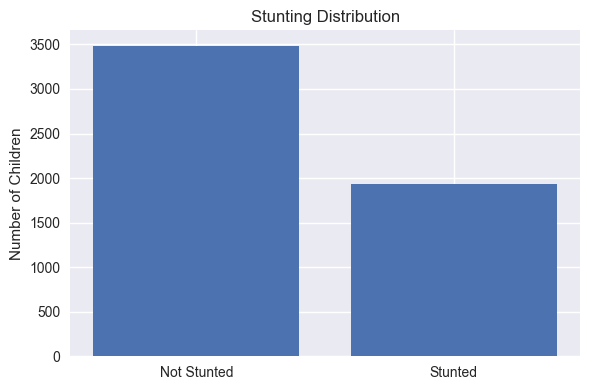

In [9]:
# Plot stunting distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df_kr_clean["stunted"].value_counts().sort_index()

ax.bar(["Not Stunted", "Stunted"], counts.values)

ax.set_title("Stunting Distribution")
ax.set_ylabel("Number of Children")

# Save figure
plt.tight_layout()
plt.savefig(FIGURES / "stunting_distribution.png", dpi=300)

plt.show()

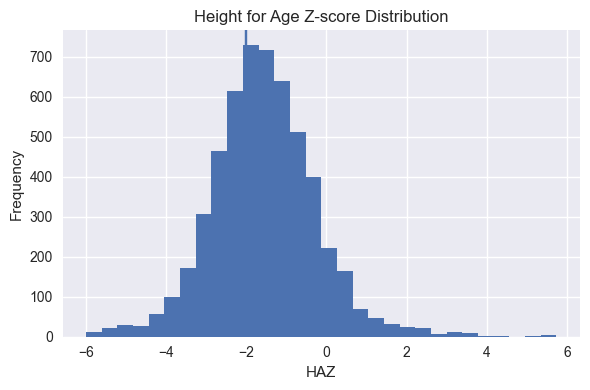

In [10]:
# Plot height-for-age distribution
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df_kr_clean["hw70"], bins=30)

# Add stunting threshold
ax.axvline(-2)

ax.set_title("Height for Age Z-score Distribution")
ax.set_xlabel("HAZ")
ax.set_ylabel("Frequency")

# Save figure
plt.tight_layout()
plt.savefig(FIGURES / "haz_distribution.png", dpi=300)

plt.show()

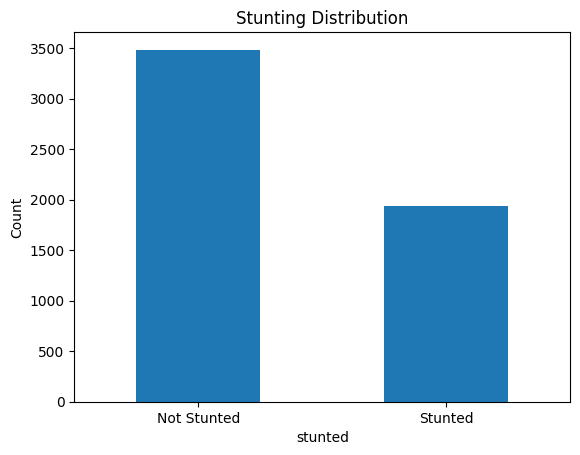

In [16]:
import matplotlib.pyplot as plt

stunting_counts = df_kr_clean["stunted"].value_counts().sort_index()

stunting_counts.plot(kind="bar")

plt.xticks([0, 1], ["Not Stunted", "Stunted"], rotation=0)
plt.title("Stunting Distribution")
plt.ylabel("Count")

plt.show()

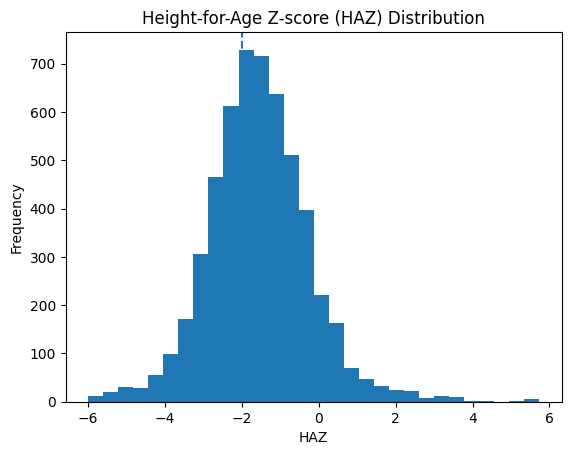

In [17]:
plt.hist(df_kr_clean["hw70"], bins=30)

plt.axvline(-2, linestyle="--")  # stunting threshold

plt.title("Height-for-Age Z-score (HAZ) Distribution")
plt.xlabel("HAZ")
plt.ylabel("Frequency")

plt.show()
